# Corpus Analysis of LLM Text

This corpus analysis will revolve around providing quantifiable metrics to the textual data by extracting its stylometry features. These features are commonly divided into different components: lexical (word choice and frequency), syntactic (grammar and sentence structure), semantic (meaning and context of words), structural (text organization), and content-specific (domain) [1,2]. 

Our text dataset have the same domains across all authors due to answering similar questions. This makes content-specific features not effective as a metric for authorship attribution. In addition to this, the structural features are also obsolete as we have prompted the LLMs to follow a specified style and formatting of the text. Aside from this, semantic features are also not effective metrics of authorship attribution, as we want to capture the style of writing rather than the meaning of written texts. As for syntactical features, we have no experience yet in dealing with these features. With these facts in mind, we decide to focus on lexical features. 

## Pre-Processing

In [1]:
import re
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk

from tokenizers import Tokenizer
from tokenizers.models import BPE

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.metrics.pairwise import cosine_similarity

### Loading the Dataset

In [2]:
# Load the merged LLM dataset
df = pd.read_csv('llm_data/llm-dataset/eli5_all_llm_answers_cleaned.csv')
print(f"Original dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Original dataset shape: (10000, 5)
Columns: ['q_id', 'question', 'chatgpt', 'deepseek', 'gemini']


,q_id,question,chatgpt,deepseek,gemini
0,5lchat,Why there was a 'leap second' added to the end...,"Okay, so imagine you have a big clock that hel...",Think of Earth like a spinning top that's slow...,Imagine we have a super-duper perfect clock th...
1,5lcjq6,How do you claim undiscovered land?,Claiming undiscovered land means saying that a...,You can't just go and claim any empty land you...,"Imagine you're exploring a giant playground, a..."
2,5lcl43,Why do we fail to do realistic human CGI (like...,"Okay, so imagine you have a really cool toy th...",We can make amazing CGI animals and monsters b...,Imagine you have a picture of your mommy or da...
3,5lcr1h,Why is it that we calm down when we take a dee...,"When you take a deep breath, it's like giving ...","When you feel scared or upset, your body gets ...",You know how sometimes when you're super excit...
4,5lcsyf,Why does 1080p on a 4k TV look better than 108...,"Okay, imagine you have two different kinds of ...",Imagine your TV screen is made of tiny light s...,Imagine your TV screen is like a giant board m...


### Separating each LLM answer into its own instance

In [3]:
# Separate each LLM answer into its own instance with an author column
instances = []

# Iterate through each row
for idx, row in df.iterrows():
    q_id = row['q_id']
    question = row['question']
    
    # Create an instance for each LLM
    for llm in ['chatgpt', 'deepseek', 'gemini']:
        instances.append({
            'q_id': q_id,
            'question': question,
            'answer': row[llm],
            'author': llm
        })

# Create the new dataframe
df = pd.DataFrame(instances)

print(f"Transformed dataset shape: {df.shape}")

print(f"\nAuthor distribution:")
print(df['author'].value_counts())

Transformed dataset shape: (30000, 4)

Author distribution:
author
chatgpt     10000
deepseek    10000
gemini      10000
Name: count, dtype: int64


## Helper Functions

In [4]:
# Extract all word lengths for each author
def get_word_lengths(text):
    return [len(word) for word in text.split()]

def calculate_ttr(text):
    words = text.lower().split()
    if len(words) == 0:
        return 0
    unique_words = len(set(words))
    total_words = len(words)
    return unique_words / total_words

# Helper Function to get top n-grams by author
def top_word_ngrams_by_author(dataframe, authors, ngram_range, top_n, min_df):
    frames = []
    for author in authors:
        texts = dataframe[dataframe["author"] == author]["answer"]

        vectorizer = CountVectorizer(lowercase=True, ngram_range=ngram_range, min_df=min_df)

        matrix = vectorizer.fit_transform(texts)
        counts = np.asarray(matrix.sum(axis = 0)).ravel()
        vocab = np.array(vectorizer.get_feature_names_out())

        if len(vocab) == 0:
            continue

        top_indices = np.argsort(-counts)[0:top_n]
        frames.append(
            pd.DataFrame(
                {
                    "author": author,
                    "ngram": vocab[top_indices],
                    "count": counts[top_indices],
                }
            )
        )
    return pd.concat(frames)

# Helper Function to get top n-grams by author
def top_char_ngrams_by_author(dataframe, authors, ngram_range, top_n, min_df, word_boundary):
    frames = []
    analyzer = 'char_wb' if word_boundary else 'char'

    for author in authors:
        texts = dataframe[dataframe["author"] == author]["answer"]
       
        vectorizer = CountVectorizer(analyzer=analyzer, lowercase=True, ngram_range=ngram_range, min_df=min_df)
        matrix = vectorizer.fit_transform(texts)
        counts = np.asarray(matrix.sum(axis = 0)).ravel()
        vocab = np.array(vectorizer.get_feature_names_out())

        if len(vocab) == 0:
            continue

        top_indices = np.argsort(-counts)[0:top_n]
        frames.append(
            pd.DataFrame(
                {
                    "author": author,
                    "ngram": vocab[top_indices],
                    "count": counts[top_indices],
                }
            )
        )
    return pd.concat(frames)

# Just for plotting the top n-grams by author
def plot_top_ngrams(ngram_df, title):
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data = ngram_df,
        x = "count",
        y = "ngram",
        hue = "author",
        dodge = True
    )
    plt.title(title)
    plt.xlabel("Count")
    plt.ylabel("N-gram")
    plt.tight_layout()
    plt.show()


def top_tf_idf_analyzer(df, analyzer, ngram_range, min_df, top_k):
    vectorizer = TfidfVectorizer(
        analyzer=analyzer,
        stop_words=None, 
        lowercase=True,
        ngram_range=ngram_range, 
        min_df=min_df,             # ignore very rare terms (appear in fewer than 5 documents)
        max_df=1.0,            #  do not ignore very common terms (can help differentiate authors)
        sublinear_tf=True     
    )

    tf_idf = vectorizer.fit_transform(df["answer"])
    terms = vectorizer.get_feature_names_out()

    tfidf_df = pd.DataFrame(tf_idf.toarray(), columns=terms)
    tfidf_df["author"] = df["author"].values

    author_means = tfidf_df.groupby("author").mean()

    top_terms_by_author = {
        a: author_means.loc[a].sort_values(ascending=False).head(top_k)
        for a in author_means.index
    }

    for a, s in top_terms_by_author.items():
        print(f"\nTop 3 {analyzer.capitalize()} {ngram_range[0]}-gram (TF-IDF) for {a}:")
        print(s.head(3))
    
    return top_terms_by_author, author_means, tf_idf


def visualize_top_tf_idf(top_terms_by_author, author_means, title):
    selected_terms = sorted(set().union(*[set(s.index) for s in top_terms_by_author.values()]))
    plot_df = author_means[selected_terms]

    plt.figure(figsize=(16, 4))
    sns.heatmap(plot_df)
    plt.title(title)
    plt.xlabel("Terms")
    plt.ylabel("Author")
    plt.tight_layout()
    plt.show()

def pairwise_cosine_similarity_matrix(author_means):
    distances = cosine_similarity(author_means)
    return distances

def avg_pairwise_cosine_similarity(author_means):
    distances = cosine_similarity(author_means)
    upper_triangle = distances[np.triu_indices_from(distances, k=1)]
    return upper_triangle.mean()

## **Lexical Features**
As mentioned before, lexical features pertain to word choice and frequency. These include well-known features such as word frequency, function word frequencies, word n-grams, character n-grams, and vocabulary richness [3]. 

For this study, we will be covering:
- Word Count Distribution
- Word Length Distribution
- Type-Token Ratio
- Function Word Frequencies

Our goal is to find metrics where the LLMs exhibit varying behavior, so that we can have them as candidate features for our models.

#### **Word Count Distribution of LLM Answers**

This metric determines if LLMs have bias towards making long or short answers based on the number of words per answer.

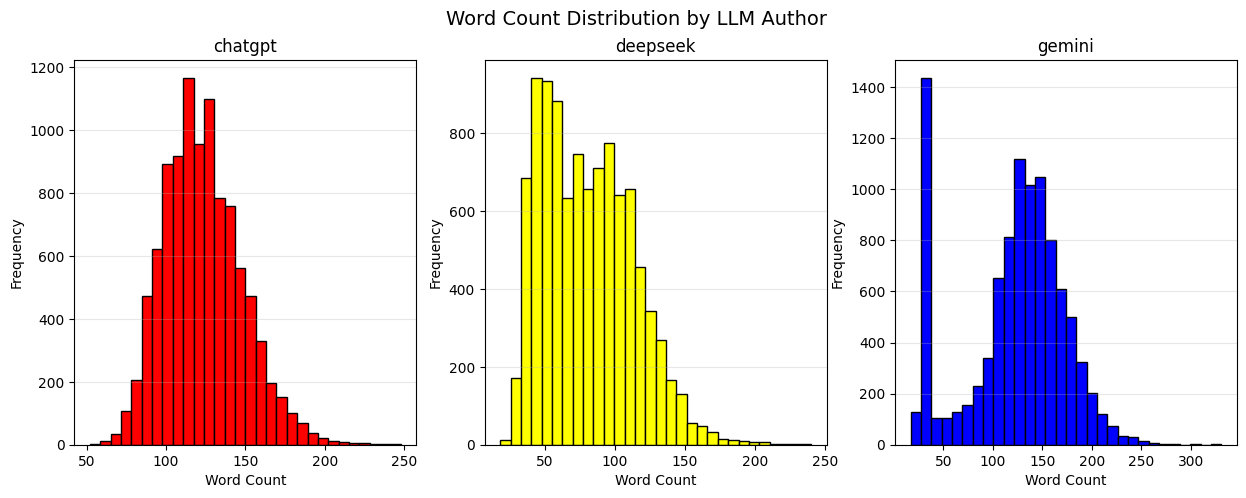

In [5]:
df['word_count'] = df['answer'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
authors = ['chatgpt', 'deepseek', 'gemini']
color = ['red', 'yellow', 'blue']

for idx, author in enumerate(authors):
    data = df[df['author'] == author]['word_count']
    axes[idx].hist(data, bins = 30, color = color[idx], edgecolor = 'black')
    axes[idx].set_title(author, fontsize = 12)
    axes[idx].set_xlabel('Word Count', fontsize = 10)
    axes[idx].set_ylabel('Frequency', fontsize = 10)
    axes[idx].grid(axis = 'y', alpha = 0.3)

plt.suptitle('Word Count Distribution by LLM Author', fontsize = 14)
plt.show()

As seen in the histogram, each LLM has a varying distribution for word count. ChatGPT seems to be less skewed than the other LLMs. With this in mind, it can be said that this metric has some potential to be used for classifying.

In [6]:
print("Word Count Statistics by LLM Author:")
print(df.groupby('author')['word_count'].describe())

Word Count Statistics by LLM Author:
            count      mean        std   min    25%    50%    75%    max
author                                                                  
chatgpt   10000.0  123.1318  24.533700  52.0  106.0  121.0  138.0  248.0
deepseek  10000.0   80.3377  32.272223  18.0   53.0   77.0  103.0  240.0
gemini    10000.0  121.7400  51.172169  17.0   98.0  130.0  156.0  331.0


#### **Word Length Distribution of LLM Answers**

This metric determines if LLMs have bias towards using long or short words based on the number of characetrs per word.

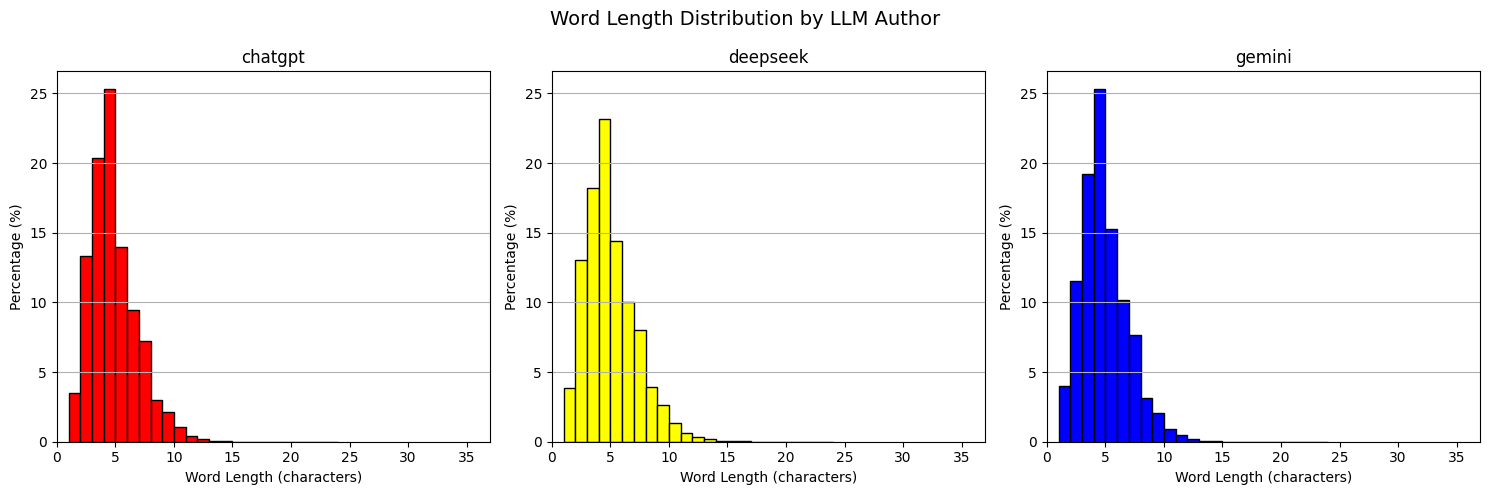

In [7]:
df['word_lengths'] = df['answer'].apply(get_word_lengths)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
authors = ['chatgpt', 'deepseek', 'gemini']
colors = ['red', 'yellow', 'blue']

# Get all word lengths for each author first to determine global max percentage
all_word_lengths = {}
for author in authors:
    word_lengths = []
    for lengths in df[df['author'] == author]['word_lengths']:
        word_lengths.extend(lengths)
    all_word_lengths[author] = word_lengths

# Get max word length across all authors for consistent x-axis
max_word_length = max(max(all_word_lengths[author]) for author in authors)

# Calculate max percentage across all authors for consistent y-axis
max_percentage = 0
for author in authors:
    counts, _ = np.histogram(all_word_lengths[author], bins = range(1, 26))
    percentages = 100 * counts / len(all_word_lengths[author])
    max_percentage = max(max_percentage, percentages.max())


# Plot with consistent axes
for idx, (author, color) in enumerate(zip(authors, colors)):
    axes[idx].hist(all_word_lengths[author], bins=range(1, 25), color = color, edgecolor = 'black', 
                   weights = 100 * np.ones(len(all_word_lengths[author])) / len(all_word_lengths[author]))
    axes[idx].set_title(author, fontsize = 12)
    axes[idx].set_xlabel('Word Length (characters)', fontsize = 10)
    axes[idx].set_ylabel('Percentage (%)', fontsize = 10)
    axes[idx].set_xlim(0, max_word_length + 1)
    axes[idx].set_ylim(0, max_percentage * 1.05)
    axes[idx].grid(axis='y')

plt.suptitle('Word Length Distribution by LLM Author', fontsize = 14)
plt.tight_layout()
plt.show()


As seen in the graph, all 3 LLMs follow similar distribution pattern in terms of word length. This means that there is little to no difference in the LLMs' bias towards short or long words. Thus, this metric has no potential to be used for classifying.

### **Type-Token Ratio**

Type-Token Ratio or TTR is a measure of vocabulary richness. It is the number of unique words used divided by the total number of words in the text [4].

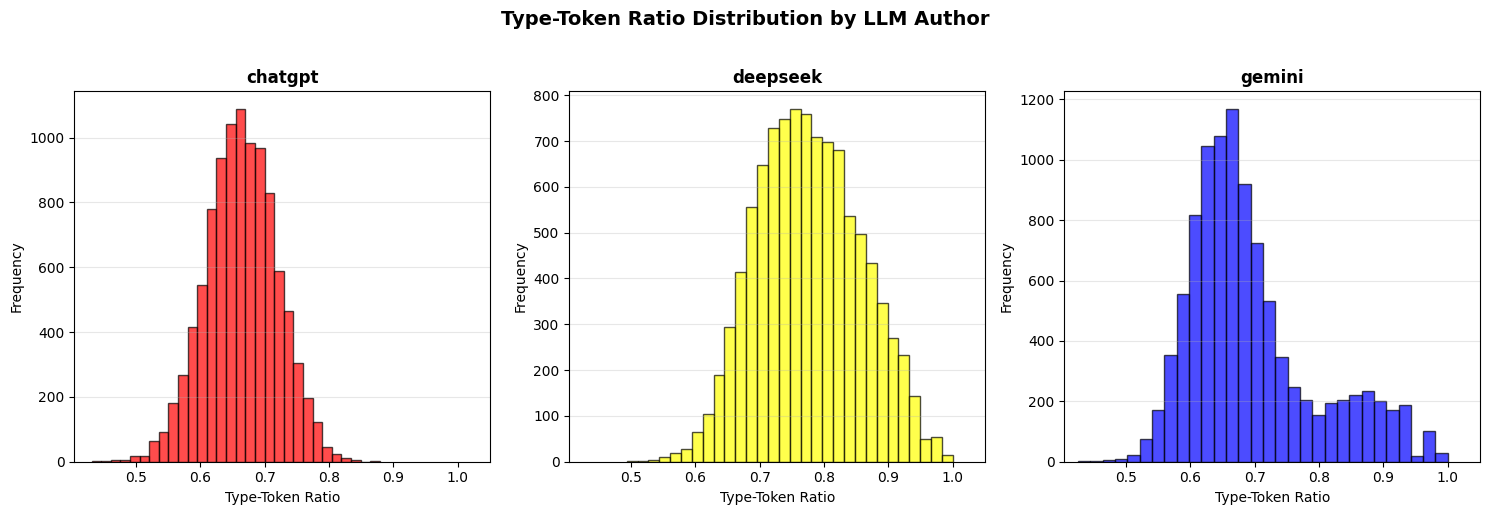


Type-Token Ratio Statistics by LLM Author:
            count      mean       std       min       25%       50%       75%  \
author                                                                          
chatgpt   10000.0  0.663900  0.054917  0.431507  0.627329  0.663866  0.701031   
deepseek  10000.0  0.776642  0.080661  0.493590  0.717172  0.773109  0.833333   
gemini    10000.0  0.694337  0.098983  0.426009  0.626761  0.669173  0.732824   

               max  
author              
chatgpt   0.878788  
deepseek  1.000000  
gemini    1.000000  


In [8]:
df['ttr'] = df['answer'].apply(calculate_ttr)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
authors = ['chatgpt', 'deepseek', 'gemini']
colors = ['red', 'yellow', 'blue']

# Calculate global min and max for consistent axes
global_min = df['ttr'].min()
global_max = df['ttr'].max()

for idx, (author, color) in enumerate(zip(authors, colors)):
    data = df[df['author'] == author]['ttr']
    axes[idx].hist(data, bins=30, color=color, edgecolor='black', alpha=0.7)
    axes[idx].set_title(author, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Type-Token Ratio', fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].set_xlim(global_min * 0.95, global_max * 1.05)
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Type-Token Ratio Distribution by LLM Author', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nType-Token Ratio Statistics by LLM Author:")
print(df.groupby('author')['ttr'].describe())

### **Function Word Frequencies**

Function words are words that have little semantic content of their own and usually indicate a grammatical relationship or generic property. The usage of these words can be considered as a marker of writing style [5].

Here, we get the density of function words in each of the LLM's outputs. We use frequency per 1k words to normalize the data. If we don't, the model would be biased to the one's with the most words, regardless if it is actually common for that LLM itself.

In [9]:
# Download stopwords if not already downloaded
nltk.download('stopwords', quiet=True)

# Get English stopwords (function words)
function_words = set(stopwords.words('english'))

# Function word frequencies for each author
author_function_words = {}
for author in authors:
    all_words = []
    for answer in df[df['author'] == author]['answer']:
        words = answer.lower().split()
        all_words.extend(words)
    
    # Count function words using a dictionary
    function_word_counts = {}
    for word in all_words:
        if word in function_words:
            function_word_counts[word] = function_word_counts.get(word, 0) + 1
    
    author_function_words[author] = function_word_counts

In [10]:
function_words = set(stopwords.words("english"))

# make all text lowercase and tokenize by splitting on non-alphabetic characters
def tokenize(text):
    return re.findall(r"[a-z']+", str(text).lower())

rows = []
for _, row in df.iterrows():
    tokens = tokenize(row["answer"])
    total_words = len(tokens)
    if total_words == 0:
        continue
    
    counts = Counter(tokens)
    for w in function_words:
        c = counts.get(w, 0) #if the word is not present, count is 0
        rows.append({
            "author": row["author"],
            "word": w,
            "count": c,
            "freq_per_1k": (c / total_words) * 1000
        })

fw = pd.DataFrame(rows)

In [11]:
# check the first few rows of the function word dataframe
top_n = 20 # for visualization purposes
top_words = (
    fw.groupby("word")["freq_per_1k"]
      .mean()
      .sort_values(ascending=False)
      .head(top_n)
      .index
)

fw_top = fw[fw["word"].isin(top_words)].copy()
print(fw_top.head())

     author  word  count  freq_per_1k
8   chatgpt   are      0     0.000000
21  chatgpt  that      1     6.896552
22  chatgpt    in      3    20.689655
23  chatgpt  when      1     6.896552
29  chatgpt   the      6    41.379310


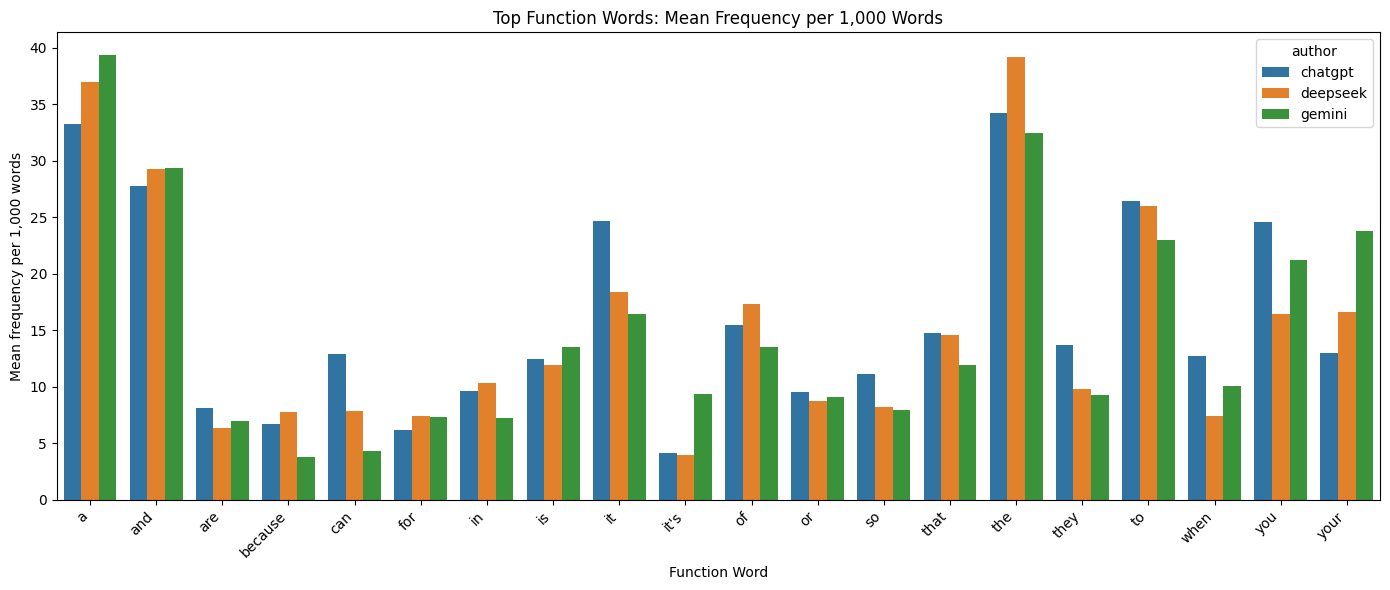

In [12]:
# visualize the top 20 function words by mean frequency per 1,000 words for each author

plt.figure(figsize=(14, 6))
mean_plot = (
    fw_top.groupby(["word", "author"])["freq_per_1k"]
    .mean()
    .reset_index()
)
sns.barplot(data=mean_plot, x="word", y="freq_per_1k", hue="author")
plt.xticks(rotation=45, ha="right")
plt.title("Top Function Words: Mean Frequency per 1,000 Words")
plt.xlabel("Function Word")
plt.ylabel("Mean frequency per 1,000 words")
plt.tight_layout()
plt.show()

From the chart above, we observe that there are words that certain LLMs use more than others. 
* "the" and deepseek
* "it" and chatgpt
* "it's" and gemini

However, there are also word frequencies that don't vary as much.
* "are"

As seen from the result, the LLMs' usage of function words varies from one model to another. This metric also has potential to be part of the features for our model.

### Word n-grams

An n-gram is essentially a string of elements which, in the context of language models, can be characters or words [6]. Prior works have explored different kinds of n-grams for classifying authorship of texts [7,8]. With this in mind, exploring this feature of our text dataset may help us to ascertain if we can use it as one of our model's features.

For this metric, we are going to be looking into word n-grams, specifically bi-grams (2-word sequence) and tri-grams (3-word sequence).  

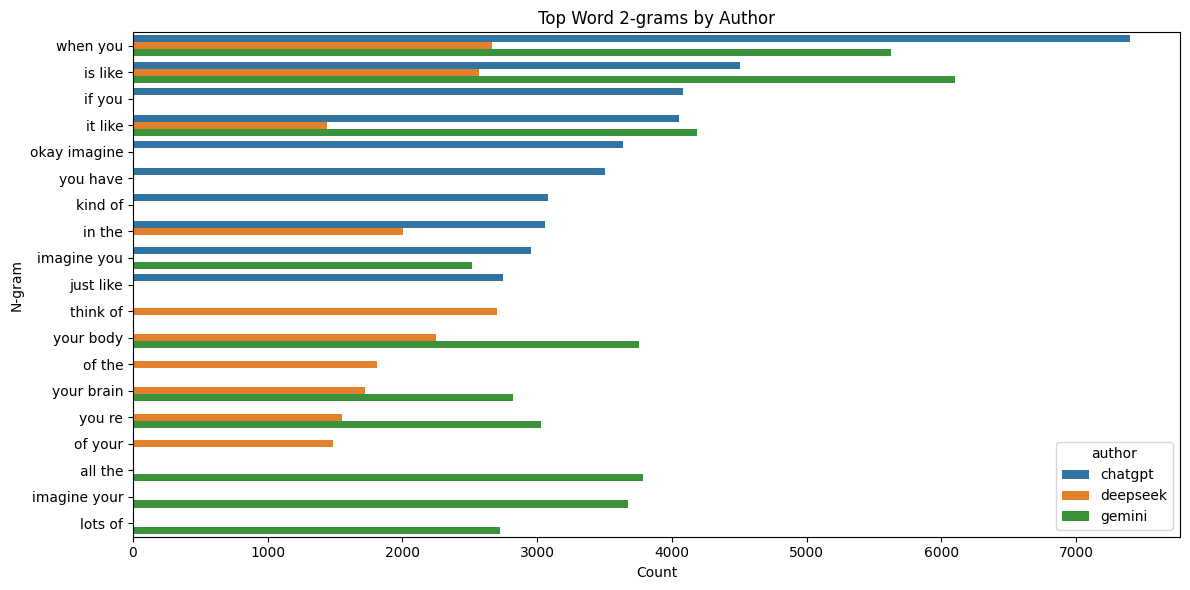

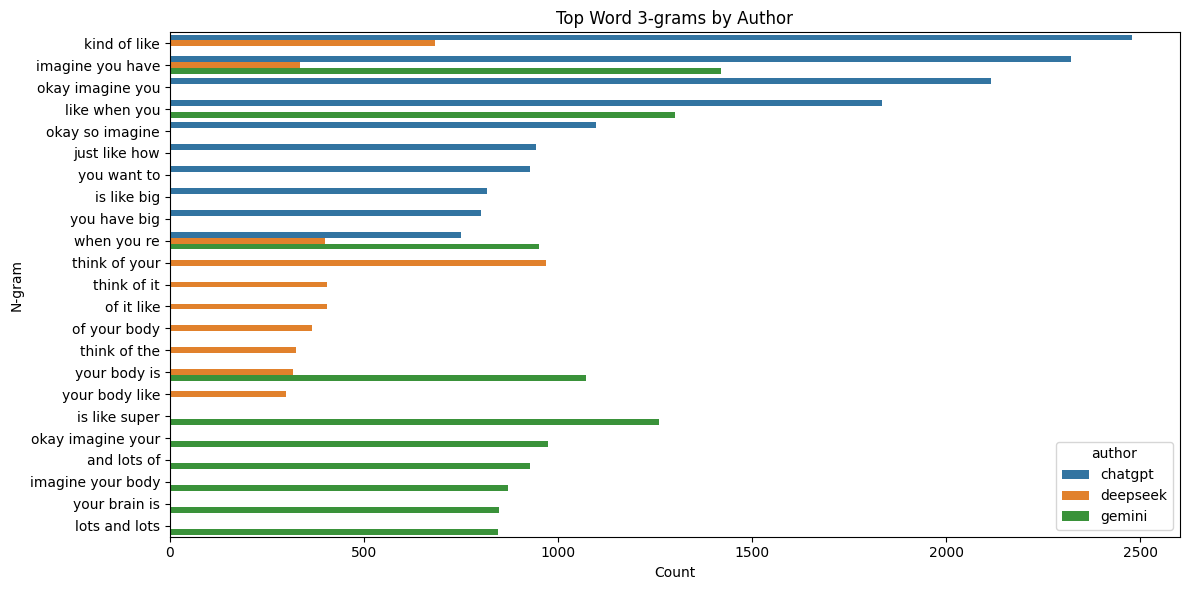

In [13]:
word_bigram_df = top_word_ngrams_by_author(df, authors, (2, 2), top_n = 10, min_df = 5)
word_trigram_df = top_word_ngrams_by_author(df, authors, (3, 3), top_n = 10, min_df = 5)

plot_top_ngrams(word_bigram_df, "Top Word 2-grams by Author")
plot_top_ngrams(word_trigram_df, "Top Word 3-grams by Author")

It is evident that each LLM has bias towards certain chain words. This kind of bias is what we'd like to explore, as it serves as a style of writing for the LLMs. 

However, we must remember that if the LLMs are using the same word n-grams, the count of words it produces may induce a "fake" bias. In this case, it can be seen that there is no normalization with respect to the amount of words. There will be a method introduced later that serves as a more robust way of normalizing.

### Character n-grams

For this metric, we are going to be looking into character n-grams, specifically 3-char n-grams. 

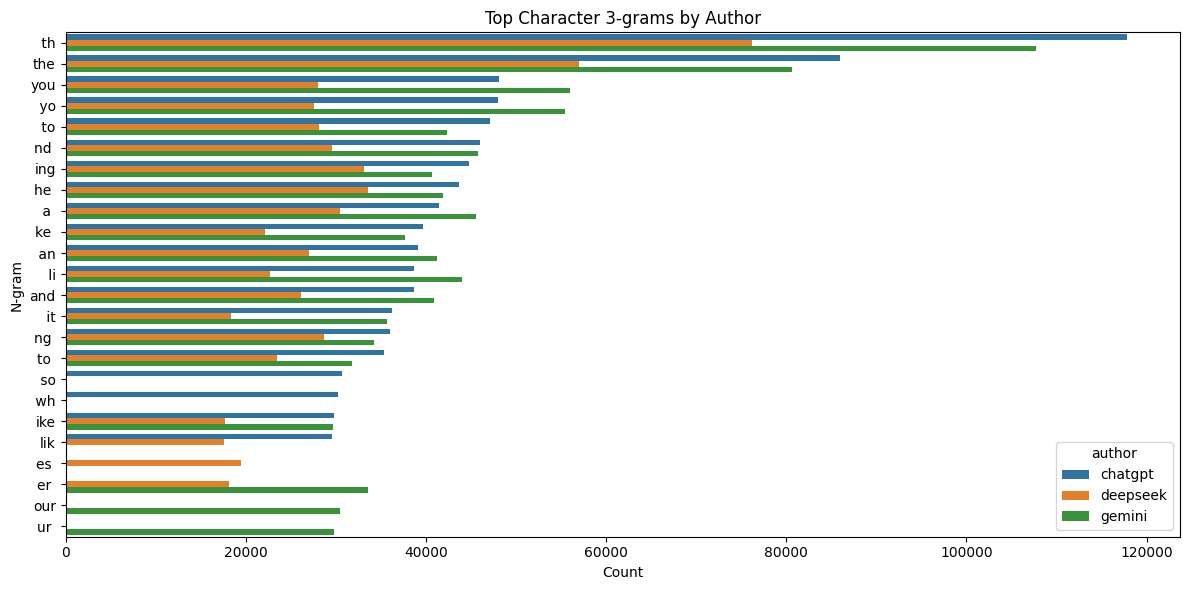

In [14]:
char_wb_trigram_df = top_char_ngrams_by_author(df, authors, (3, 3), top_n = 20, min_df = 5, word_boundary = True)

plot_top_ngrams(char_wb_trigram_df, "Top Character 3-grams by Author")


Similar to the word n-grams, the usage of character n-grams are varied across the LLMs. In the case where all 3 are using the same character n-grams, the differences in occurence may be affected by the length of the answers, and not just the bias of the LLM to use such charcter n-gram. 

To address this issue for both character and word n-grams, we will be introducing Term Frequency-Inverse Document Frequency.

***

## **Term Frequency–Inverse Document Frequency (TF-IDF)**

TF-IDF is a statistical method used in natural language processing and information retrieval to evaluate how important a word is to a document in relation to a larger collection of documents. Some of its applications include evaluating document similarity and text classification, both of which are similar to authorship attribution [9]. In fact, prior works have used this metric for authorship attribution [10, 11, 12].

The formula for TF-IDF is as follows:

$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$

where,
$$\text{TF}(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in document } d}$$

$$\text{IDF}(t, D) = \log \left( \frac{\text{Total number of documents } N}{\text{Number of documents containing term } t} \right)$$

Since we have observed that there are words that certain authors use more, TF-IDF can help distinguish more patterns and be a better dataset to train machine learning models.

In addition to this, we will further explore TF-IDF by getting the cosine similarity between the means of the TF-IDF per author.

### Word 2-gram TF-IDF

Justifications:
1. stop_words=none :  we don't want to remove these since it's established that they vary by author
2. min_df=5 : ignore very rare terms (appear in fewer than 5 documents)
3. max_df=1.0 : do not ignore very common terms (can help differentiate authors)
4. sublinear_tf=True : since we don't ignore common terms, this helps very repetitive words from dominating

In [15]:
top_terms_by_author, author_means, tf_idf = top_tf_idf_analyzer(df, analyzer='word', ngram_range=(2, 2), min_df=5, top_k=15)


Top 3 Word 2-gram (TF-IDF) for chatgpt:
when you        0.019744
if you          0.014387
okay imagine    0.013874
Name: chatgpt, dtype: float64

Top 3 Word 2-gram (TF-IDF) for deepseek:
think of     0.015825
your body    0.010794
when you     0.010185
Name: deepseek, dtype: float64

Top 3 Word 2-gram (TF-IDF) for gemini:
is like         0.018891
imagine your    0.016615
when you        0.015442
Name: gemini, dtype: float64


In [16]:
print(f"Avg pairwise cosine similarity (word 2-gram): {avg_pairwise_cosine_similarity(author_means):.4f}")

Avg pairwise cosine similarity (word 2-gram): 0.7980


In [17]:
pairwise_cosine_similarity_matrix(author_means)

array([[1.        , 0.83194531, 0.78810073],
       [0.83194531, 1.        , 0.77395997],
       [0.78810073, 0.77395997, 1.        ]])

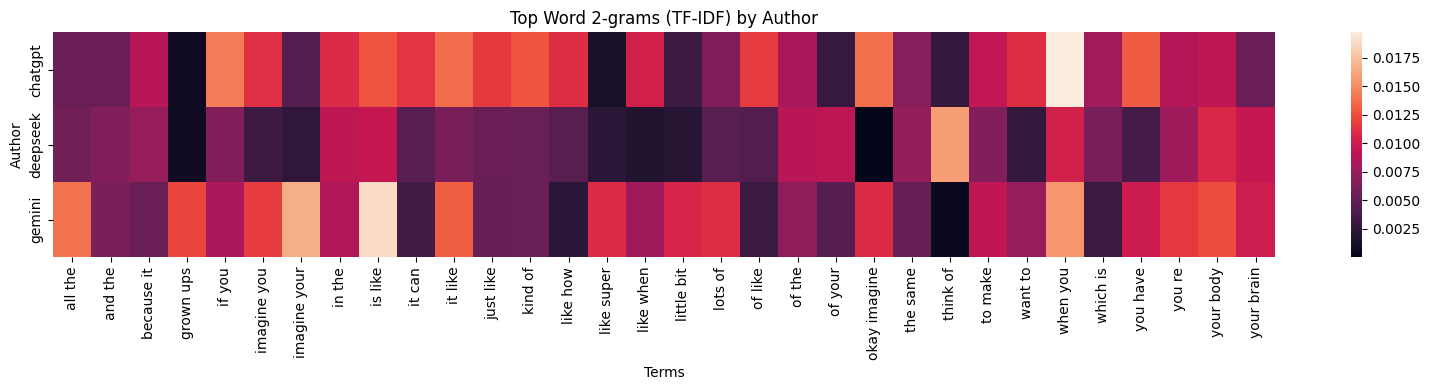

In [18]:
visualize_top_tf_idf(top_terms_by_author, author_means, "Top Word 2-grams (TF-IDF) by Author")

### Word 3-gram TF-IDF

In [19]:
top_terms_by_author, author_means, tf_idf = top_tf_idf_analyzer(df, analyzer='word', ngram_range=(3, 3), min_df=5, top_k=15)


Top 3 Word 3-gram (TF-IDF) for chatgpt:
kind of like        0.013429
okay imagine you    0.012184
imagine you have    0.011834
Name: chatgpt, dtype: float64

Top 3 Word 3-gram (TF-IDF) for deepseek:
think of your    0.009984
kind of like     0.005739
think of it      0.005022
Name: deepseek, dtype: float64

Top 3 Word 3-gram (TF-IDF) for gemini:
is like super        0.009795
imagine you have     0.009465
okay imagine your    0.007731
Name: gemini, dtype: float64


In [20]:
print(f"Avg pairwise cosine similarity (word 3-gram): {avg_pairwise_cosine_similarity(author_means):.4f}")

Avg pairwise cosine similarity (word 3-gram): 0.6218


In [21]:
pairwise_cosine_similarity_matrix(author_means)

array([[1.        , 0.64864411, 0.63768485],
       [0.64864411, 1.        , 0.5789553 ],
       [0.63768485, 0.5789553 , 1.        ]])

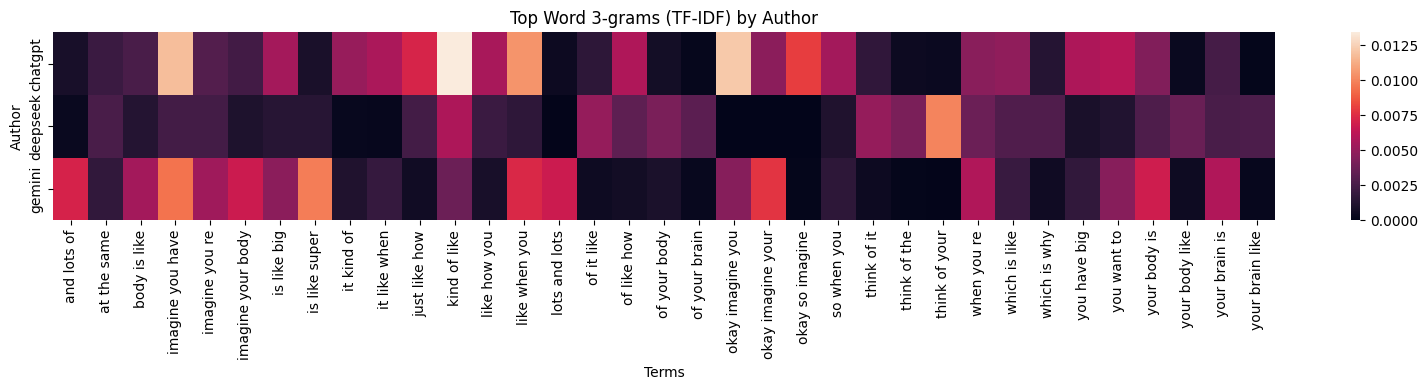

In [22]:
visualize_top_tf_idf(top_terms_by_author, author_means, "Top Word 3-grams (TF-IDF) by Author")

## Character 3-gram TF-IDF

In [23]:
top_terms_by_author, author_means, tf_idf = top_tf_idf_analyzer(df, analyzer='char', ngram_range=(3, 3), min_df=5, top_k=15)


Top 3 Char 3-gram (TF-IDF) for chatgpt:
 th    0.048023
the    0.043195
 yo    0.035890
Name: chatgpt, dtype: float64

Top 3 Char 3-gram (TF-IDF) for deepseek:
 th    0.047765
the    0.042682
ing    0.034976
Name: deepseek, dtype: float64

Top 3 Char 3-gram (TF-IDF) for gemini:
 th    0.044653
you    0.040682
 yo    0.040368
Name: gemini, dtype: float64


In [24]:
print(f"Avg pairwise cosine similarity (character 3-gram): {avg_pairwise_cosine_similarity(author_means):.4f}")

Avg pairwise cosine similarity (character 3-gram): 0.9426


In [25]:
pairwise_cosine_similarity_matrix(author_means)

array([[1.        , 0.95984594, 0.93862929],
       [0.95984594, 1.        , 0.92920658],
       [0.93862929, 0.92920658, 1.        ]])

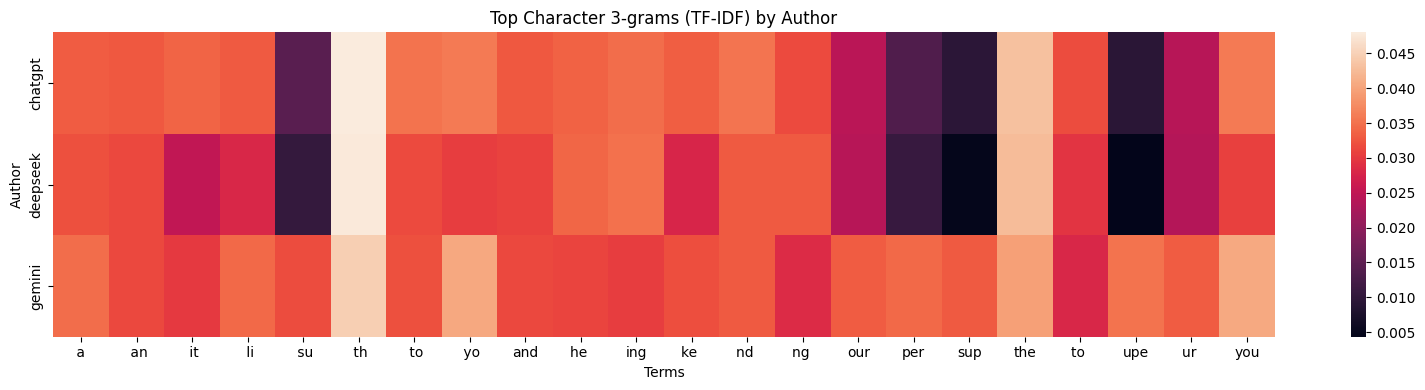

In [26]:
visualize_top_tf_idf(top_terms_by_author, author_means, "Top Character 3-grams (TF-IDF) by Author")

### Character 4-gram TF-IDF

In [27]:
top_terms_by_author, author_means, tf_idf = top_tf_idf_analyzer(df, analyzer='char', ngram_range=(4, 4), min_df=5, top_k=15)


Top 3 Char 4-gram (TF-IDF) for chatgpt:
 the    0.030010
 you    0.025779
the     0.023981
Name: chatgpt, dtype: float64

Top 3 Char 4-gram (TF-IDF) for deepseek:
 the    0.028917
the     0.024200
ing     0.022877
Name: deepseek, dtype: float64

Top 3 Char 4-gram (TF-IDF) for gemini:
 you    0.029270
 the    0.027837
uper    0.025457
Name: gemini, dtype: float64


In [28]:
print(f"Avg pairwise cosine similarity (character 4-gram): {avg_pairwise_cosine_similarity(author_means):.4f}")

Avg pairwise cosine similarity (character 4-gram): 0.9093


In [29]:
pairwise_cosine_similarity_matrix(author_means)

array([[1.        , 0.93405606, 0.90204965],
       [0.93405606, 1.        , 0.89177516],
       [0.90204965, 0.89177516, 1.        ]])

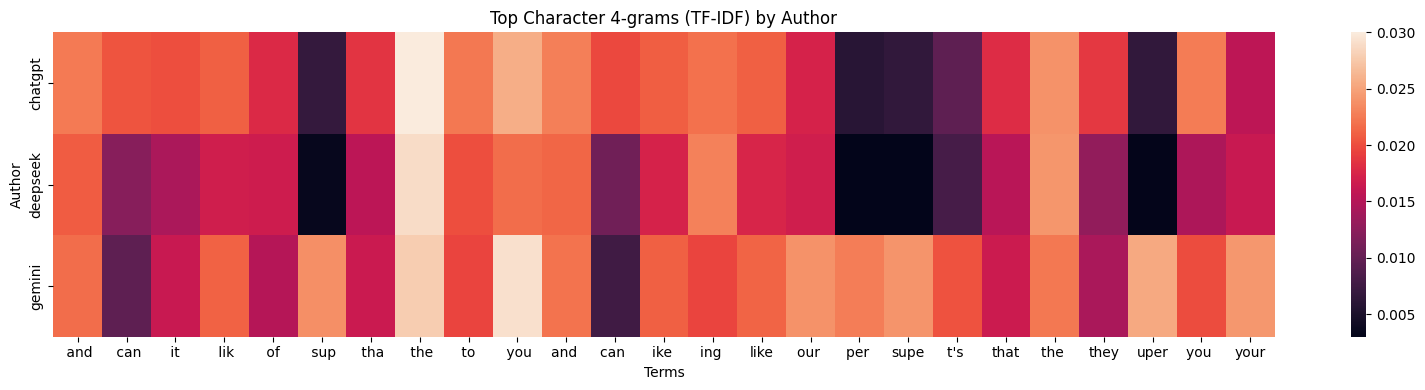

In [30]:
visualize_top_tf_idf(top_terms_by_author, author_means, "Top Character 4-grams (TF-IDF) by Author")


Similar with word n-grams, the character n-grams exhibit varying usage across different LLM authors. However, in terms of cosine similarity across the TF-IDF of all the authors, it can be said that that word n-grams show less similarity compared to character n-grams. This means that word n-grams might have more potential compared to character n-grams.

## References

[1] 
Neal, T., Sundararajan, K., Fatima, A., Yan, Y., Xiang, Y., & Woodard, D. (2017). Surveying stylometry techniques and applications. 
    ACM Computing Surveys (CSuR), 50(6), 1-36.

[2]
Huang, B., Chen, C., & Shu, K. (2025). Authorship attribution in the era of llms: Problems, methodologies, and challenges. ACM SIGKDD 
    Explorations Newsletter, 26(2), 21-43.
    
[3]
Stamatatos, E. (2009). A survey of modern authorship attribution methods. Journal of the American Society for information Science and Technology, 
    60(3), 538-556.

[4] 
Sketch Engine. (2024, November 13). Type-token ratio (TTR). https://www.sketchengine.eu/glossary/type-token-ratio-ttr/

[5]
Zhao, Y., & Zobel, J. (2005, October). Effective and scalable authorship attribution using function words. In Asia Information Retrieval Symposium 
    (pp. 174-189). Berlin, Heidelberg: Springer Berlin Heidelberg.

[6] 
Jurafsky, D., & Martin, J. H. (2023). Speech and language processing (3rd ed. draft). https://web.stanford.edu/~jurafsky/slp3/

[7]
Sapkota, U., Bethard, S., Montes, M., & Solorio, T. (2015). Not all character n-grams are created equal: A study in authorship attribution. In 
    Proceedings of the 2015 conference of the North American chapter of the association for computational linguistics: Human language technologies (pp. 93-102).
   
[8]
    Stamatatos, P. D. (2013). On the robustness of authorship attribution based on character n-gram features. Journal of law and policy, 21(2), 7.

[9]
GeeksforGeeks. (2021, January 20). Understanding TFIDF (Term FrequencyInverse Document Frequency). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/

[10]
Lorenz, L., Aygüler, F. Z., Schlatt, F., & Mirzakhmedova, N. (2024). BaselineAvengers at PAN 2024: Often-forgotten baselines for LLM-generated text detection. In G. Faggioli, N. Ferro, P. Galuščáková, & A. García Seco de Herrera (Eds.), Working Notes of the Conference and Labs of the Evaluation Forum (CLEF 2024) (CEUR Workshop Proceedings, Vol. 3740, pp. 2761–2768). CEUR-WS. https://ceur-ws.org/Vol-3740/paper-262.pdf

[11]
Abedzadeh, Ali, Reza Ramezani, and Afsaneh Fatemi. "A weighted TF-IDF-based approach for authorship attribution." 2021 11th International Conference on Computer Engineering and Knowledge (ICCKE). IEEE, 2021.

[12]
Gupta, S., Das, S., & Mallik, J. R. (2022). Machine learning-based authorship attribution using token n-grams and other time tested features. International Journal of Hybrid Intelligent Systems, 18(1-2), 37-51.